# Project 3 : COVID-19 Data Analysis
---
### Project Work Done By:
## Mahrin Jawwad Arab
---
## Objective
This project performs exploratory data analysis (EDA) on global COVID-19 data to understand trends in cases and deaths across different countries. The analysis focuses on selected countries and visualizes patterns using Python data visualization libraries.

## Step 1: Import Required Libraries

In this step, we import the libraries required for data analysis and visualization.

- **Pandas** – for data manipulation and analysis  
- **Matplotlib** – for basic plotting  
- **Seaborn** – for advanced data visualization

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Step 2: Load the Dataset

The dataset used in this project is obtained from **Our World in Data**.  
It contains global COVID-19 statistics including cases, deaths, and other related metrics.

We load the dataset using Pandas and preview the first few rows.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving owid-covid-data.csv to owid-covid-data.csv


In [ ]:
df = pd.read_csv("owid-covid-data.csv")

df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


## Step 3: Inspect the Dataset

Before performing analysis, it is important to understand the structure of the dataset.

In this step we:
- Check column names
- Check data types
- Identify missing values

In [ ]:
print(df.info())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350085 entries, 0 to 350084
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    350085 non-null  object 
 1   continent                                   333420 non-null  object 
 2   location                                    350085 non-null  object 
 3   date                                        350085 non-null  object 
 4   total_cases                                 312088 non-null  float64
 5   new_cases                                   340457 non-null  float64
 6   new_cases_smoothed                          339198 non-null  float64
 7   total_deaths                                290501 non-null  float64
 8   new_deaths                                  340511 non-null  float64
 9   new_deaths_smoothed                         339281 non-null  float64
 

## Step 4: Select Relevant Columns

The dataset contains many columns, but for this analysis we focus on key variables:

- location
- date
- total_cases
- new_cases
- total_deaths

Selecting only necessary columns helps simplify the analysis.

In [ ]:
df = df[[
    "location",
    "date",
    "total_cases",
    "new_cases",
    "total_deaths"
]]

## Step 4.1: Distribution of Daily Cases

Understanding the distribution of daily COVID-19 cases helps identify how frequently high or low case counts occur and whether extreme spikes are present in the dataset.

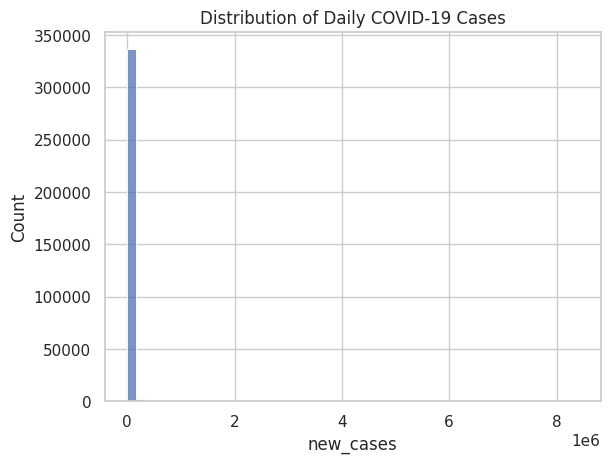

In [ ]:
sns.histplot(df["new_cases"], bins=50)

plt.title("Distribution of Daily COVID-19 Cases")

plt.show()

## Step 5: Convert Date Column

The date column is converted into a proper datetime format so that time-series analysis can be performed.

In [ ]:
df["date"] = pd.to_datetime(df["date"])

## Step 5.1: Correlation Analysis

Correlation analysis helps identify relationships between key variables such as total cases, new cases, and total deaths.

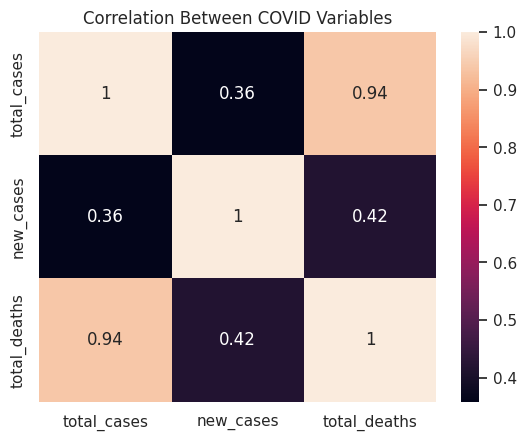

In [ ]:
correlation = df[["total_cases","new_cases","total_deaths"]].corr()

sns.heatmap(correlation, annot=True)

plt.title("Correlation Between COVID Variables")

plt.show()

## Step 6: Filter Selected Countries

To make the analysis more meaningful, we select a few countries for comparison.

Countries selected for this project:
- India
- United States
- Brazil
- United Kingdom

In [ ]:
countries = ["India", "United States", "Brazil", "United Kingdom"]

df = df[df["location"].isin(countries)]

## Step 7: Visualize Daily COVID-19 Cases

This visualization shows how the number of new COVID-19 cases changes over time for the selected countries.

The line chart helps identify trends, peaks, and waves of infection.

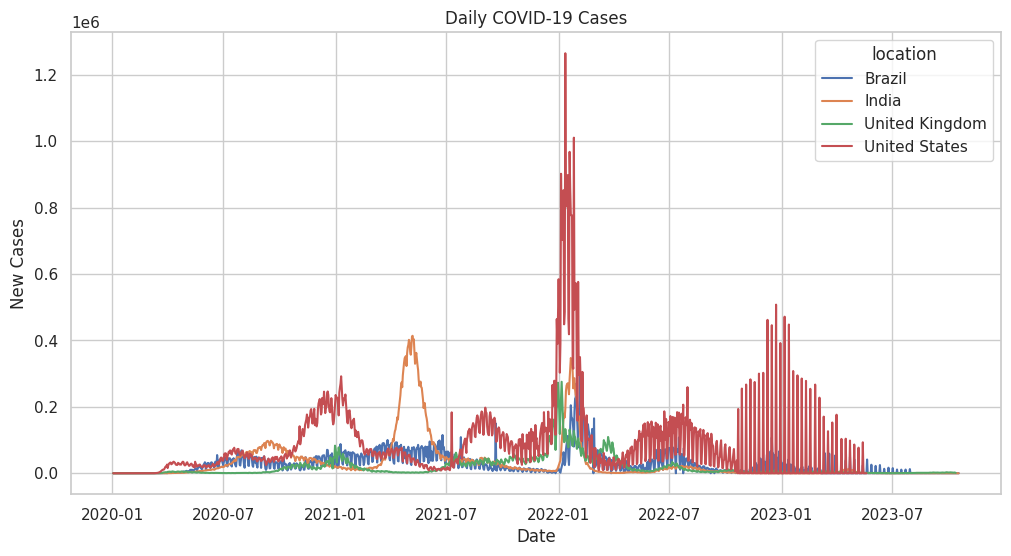

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(data=df, x="date", y="new_cases", hue="location")

plt.title("Daily COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")

plt.show()

## Step 8: Calculate 7-Day Rolling Average

Daily case numbers can fluctuate significantly.  
A **7-day rolling average** smooths the data and provides a clearer view of the trend.

In [ ]:
df["rolling_cases"] = df.groupby("location")["new_cases"] \
                        .rolling(7).mean().reset_index(0, drop=True)

## Step 9: Visualize 7-Day Rolling Average

This chart shows the smoothed trend of COVID-19 cases using the rolling average.
It helps identify waves of infection more clearly.

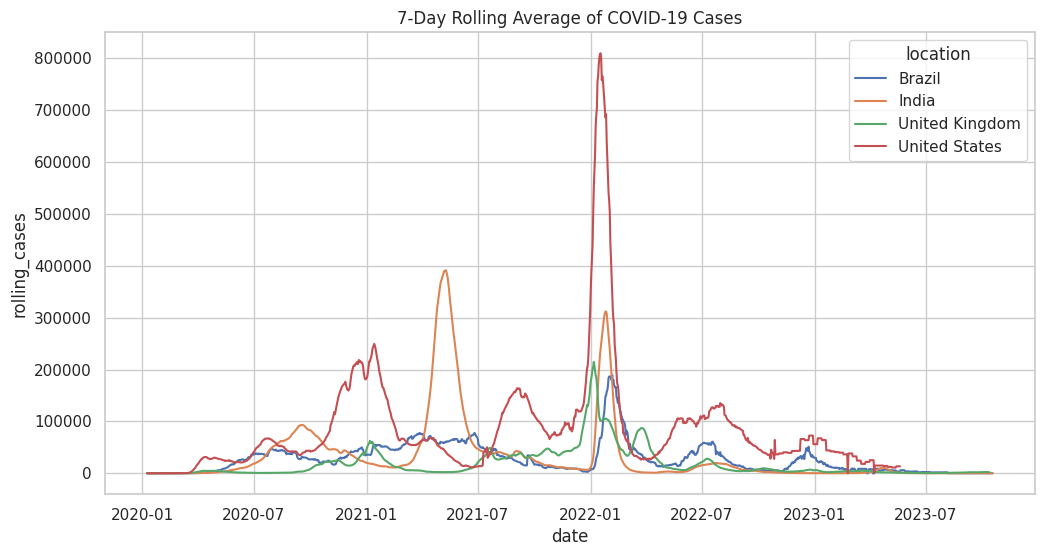

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(data=df, x="date", y="rolling_cases", hue="location")

plt.title("7-Day Rolling Average of COVID-19 Cases")

plt.show()

## Step 10: Compare Peak Case Counts

This bar chart compares the highest number of daily cases recorded in each selected country.

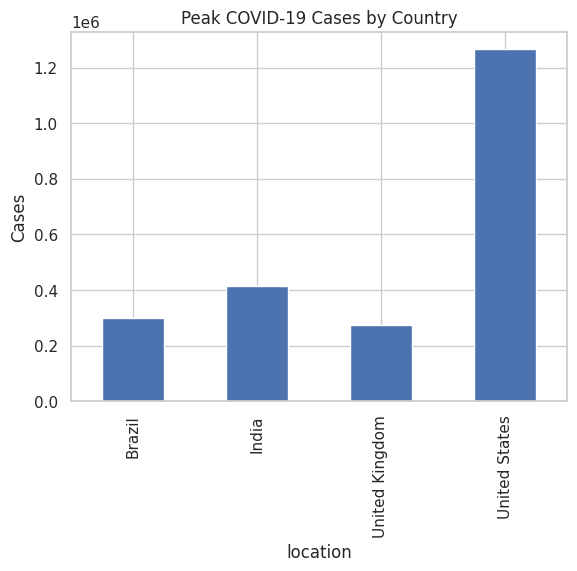

In [ ]:
peak_cases = df.groupby("location")["new_cases"].max()

peak_cases.plot(kind="bar")

plt.title("Peak COVID-19 Cases by Country")

plt.ylabel("Cases")

plt.show()

## Step 10.1: Death Rate Analysis

To better understand the severity of COVID-19 across countries, we calculate the death rate using total deaths and total confirmed cases.

In [ ]:
df["death_rate"] = (df["total_deaths"] / df["total_cases"]) * 100

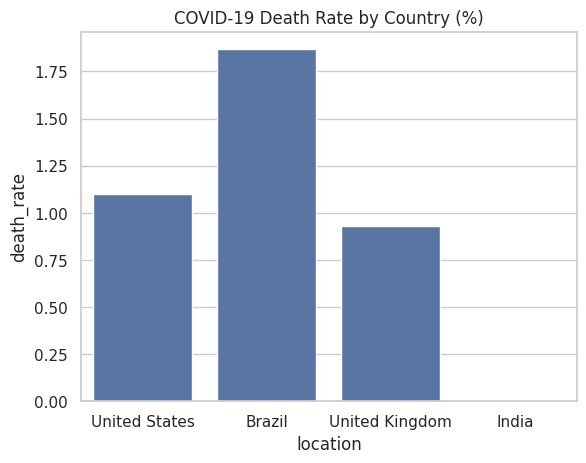

In [ ]:
latest = df.sort_values("date").groupby("location").tail(1)

sns.barplot(data=latest, x="location", y="death_rate")

plt.title("COVID-19 Death Rate by Country (%)")

plt.show()

## Step 11: Compare Total Cases

This visualization compares the total number of COVID-19 cases recorded in each selected country.

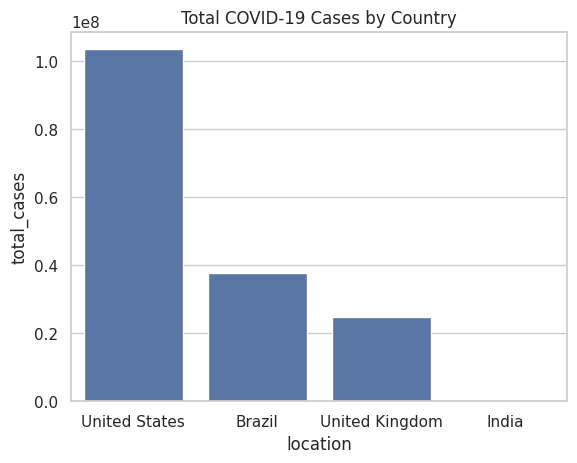

In [ ]:
latest = df.sort_values("date").groupby("location").tail(1)

sns.barplot(data=latest, x="location", y="total_cases")

plt.title("Total COVID-19 Cases by Country")

plt.show()

## Key Insights

From the analysis we observe:

- COVID-19 cases occurred in multiple waves across countries.
- The United States experienced early large outbreaks.
- India recorded very high peaks during later waves.
- Rolling averages help identify trends by smoothing daily fluctuations.

## Conclusion

This project performed an exploratory data analysis (EDA) on global COVID-19 data to understand how the pandemic evolved across different countries. By analyzing key variables such as daily cases, total cases, and deaths, we were able to identify trends and patterns in the spread of the virus.

The visualizations showed that COVID-19 cases occurred in multiple waves, with different countries experiencing peaks at different time periods. The 7-day rolling average helped smooth daily fluctuations and provided a clearer view of overall trends. Comparisons between countries also highlighted differences in the scale and timing of outbreaks.

Overall, this analysis demonstrates how data visualization and time-series analysis can help interpret large public health datasets and reveal meaningful insights about global events such as the COVID-19 pandemic.